In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import datetime
import hydrostats as hm

In [2]:
path_to_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/model_runs/complete_seperate_run/outputs/optuna_monthly_calibration/run_0ad2d50b/netcdf/discharge_dailyTot_output.nc"


ds = xr.open_dataset(path_to_file)  

In [3]:
import numpy as np
def plot_discharge_around_station(da, station_lat, station_lon, time_idx=60, window=5):
    time_idx = time_idx
    window = window  # number of grid cells around the nearest station cell

    da_t = da.isel(time=time_idx)

    # Find nearest grid-cell indices to station coordinates
    lat_vals = da_t.lat.values
    lon_vals = da_t.lon.values
    lat_idx = int(np.abs(lat_vals - station_lat).argmin())
    lon_idx = int(np.abs(lon_vals - station_lon).argmin())

    lat_start = max(0, lat_idx - window)
    lat_end = min(da_t.sizes["lat"], lat_idx + window + 1)
    lon_start = max(0, lon_idx - window)
    lon_end = min(da_t.sizes["lon"], lon_idx + window + 1)

    subset = da_t.isel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))

    fig, ax = plt.subplots(figsize=(7, 6))
    subset.plot(ax=ax, cmap="viridis")
    ax.scatter(station_lon, station_lat, color="red", s=60, marker="x", label="Station")
    ax.set_title(f"Discharge around station at time index {time_idx}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()
    plt.tight_layout()

def plot_discharge_around_example(da, time_idx=60, window=5):
    time_idx = time_idx
    window = window  # number of grid cells around the nearest station cell
    station_lat = 37.21
    station_lon = 67.31
    corrected_lat = 37.29
    corrected_lon = 67.45

    da_t = da.isel(time=time_idx)
    #da_t_time = da_t.time.values
    time_string = da_t.time.dt.strftime("%Y-%m-%d").item()

    # Find nearest grid-cell indices to station coordinates
    lat_vals = da_t.lat.values
    lon_vals = da_t.lon.values
    lat_idx = int(np.abs(lat_vals - station_lat).argmin())
    lon_idx = int(np.abs(lon_vals - station_lon).argmin())

    lat_start = max(0, lat_idx - window)
    lat_end = min(da_t.sizes["lat"], lat_idx + window + 1)
    lon_start = max(0, lon_idx - window)
    lon_end = min(da_t.sizes["lon"], lon_idx + window + 1)

    subset = da_t.isel(lat=slice(lat_start, lat_end), lon=slice(lon_start, lon_end))

    fig, ax = plt.subplots(figsize=(7, 6))
    subset.plot(ax=ax, cmap="viridis")
    ax.scatter(
        station_lon,
        station_lat,
        color="red",
        edgecolors="black",
        linewidths=1.5,
        s=60,
        marker="o",
        label="Station: GRDC coordinates"
    )

    ax.scatter(
        corrected_lon,
        corrected_lat,
        color="yellow",
        edgecolors="black",
        linewidths=1.5,
        s=60,
        marker="o",
        label="Station: Adjusted coordinates"
    )
    ax.set_title(f"Modeled discharge around station on {time_string}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(loc="lower right")
    plt.tight_layout()


def plot_timeseries_at_station(da, station_lat, station_lon, startup_time_idx=60):
    discharge_time_series = da.sel(lat=station_lat, lon=station_lon, method="nearest")
    discharge_time_series = discharge_time_series.isel(time=slice(startup_time_idx, None))
    plt.figure(figsize=(10, 4))
    plt.plot(discharge_time_series.time.values, discharge_time_series.values)
    plt.xlabel("Time")
    plt.ylabel("Discharge")
    plt.title("Discharge Time Series")
    plt.grid()
    plt.tight_layout()

def plot_monthly_discharge_at_station(da, station_lat, station_lon, startup_time_idx=60):
    discharge_time_series = da.sel(lat=station_lat, lon=station_lon, method="nearest")
    discharge_time_series = discharge_time_series.isel(time=slice(startup_time_idx, None))
    discharge_time_series = discharge_time_series.sel(time=slice("1950-01-01", "1950-12-31"))
    monthly_discharge = discharge_time_series.groupby("time.month").mean(dim="time")
    plt.figure(figsize=(10, 4))
    plt.plot(monthly_discharge.month, monthly_discharge.values)
    plt.xlabel("Month")
    plt.ylabel("Average Discharge")
    plt.title("Average Monthly Discharge")
    plt.grid()
    plt.tight_layout()

def calc_monthly_discharge_at_station(da, station_lat, station_lon, start_date="1950-01-01", end_date="1950-12-31", startup_time_idx=60):
    """Calculate monthly average discharge at a station over a date range."""
    discharge_time_series = da.sel(lat=station_lat, lon=station_lon, method="nearest")
    discharge_time_series = discharge_time_series.sel(time=slice(start_date, end_date))
    monthly_discharge = discharge_time_series.groupby("time.month").mean(dim="time")
    to_dataframe = monthly_discharge.to_dataframe().reset_index()
    return to_dataframe

In [4]:
ds

<xarray.Dataset> Size: 114MB
Dimensions:    (time: 549, lat: 180, lon: 288)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1949-07-01 1949-07-02 ... 1950-12-31
  * lat        (lat) float32 720B 47.96 47.88 47.79 47.71 ... 33.21 33.12 33.04
  * lon        (lon) float32 1kB 53.04 53.12 53.21 53.29 ... 76.79 76.88 76.96
Data variables:
    discharge  (time, lat, lon) float32 114MB ...
Attributes:
    institution:  Department of Physical Geography, Utrecht University
    title:        PCR-GLOBWB 2 output (not coupled to MODFLOW)
    description:  by Edwin H. Sutanudjaja (contact: e.h.sutanudjaja@uu.nl)

In [5]:
da = ds["discharge"]
da_t = da.isel(time=-60)
print(da_t.time.dt.strftime("%Y-%m-%d").item())

1950-11-02


Nearest grid point to station: lat=37.79166793823242, lon=65.29166412353516


,month,lat,lon,discharge
0,1,37.791668,65.291664,6.973210
1,2,37.791668,65.291664,4.888290
2,3,37.791668,65.291664,46.120327
3,4,37.791668,65.291664,105.813133
4,5,37.791668,65.291664,215.064270
5,6,37.791668,65.291664,166.642014
6,7,37.791668,65.291664,710.599854
7,8,37.791668,65.291664,986.816650
8,9,37.791668,65.291664,80.674858
9,10,37.791668,65.291664,8.134620


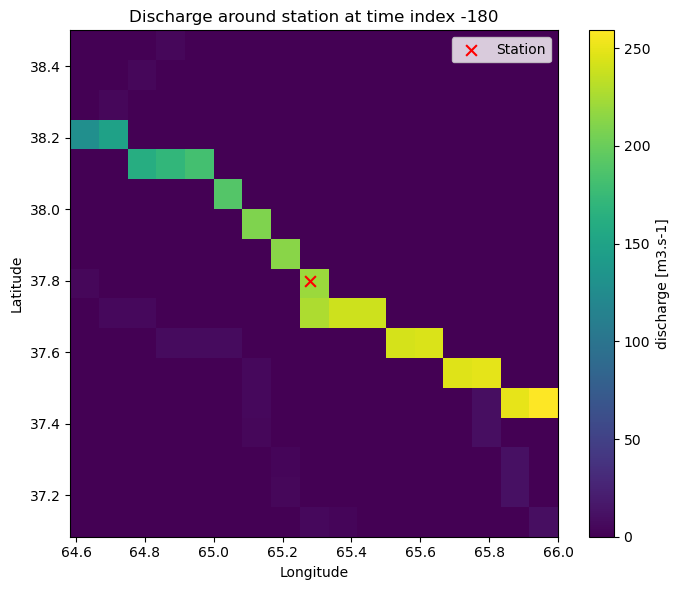

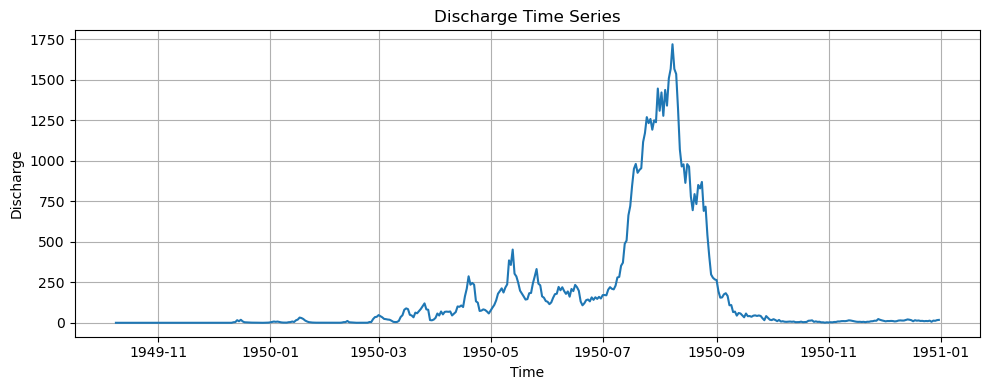

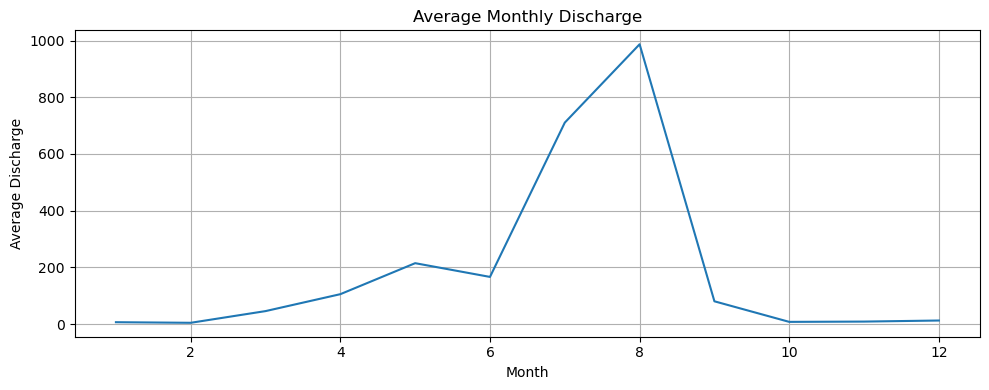

In [9]:
station_lat = 37.80
station_lon = 65.28

# Find the nearest grid point to the station
nearest_lat = da.lat.sel(lat=station_lat, method="nearest")
nearest_lon = da.lon.sel(lon=station_lon, method="nearest")
print(f"Nearest grid point to station: lat={nearest_lat.values}, lon={nearest_lon.values}")
plot_discharge_around_station(da, station_lat, station_lon, time_idx=-180, window=8)

plot_timeseries_at_station(da, station_lat, station_lon,100)

plot_monthly_discharge_at_station(da, station_lat, station_lon,100)
df_to_print = calc_monthly_discharge_at_station(da, station_lat, station_lon)
df_to_print


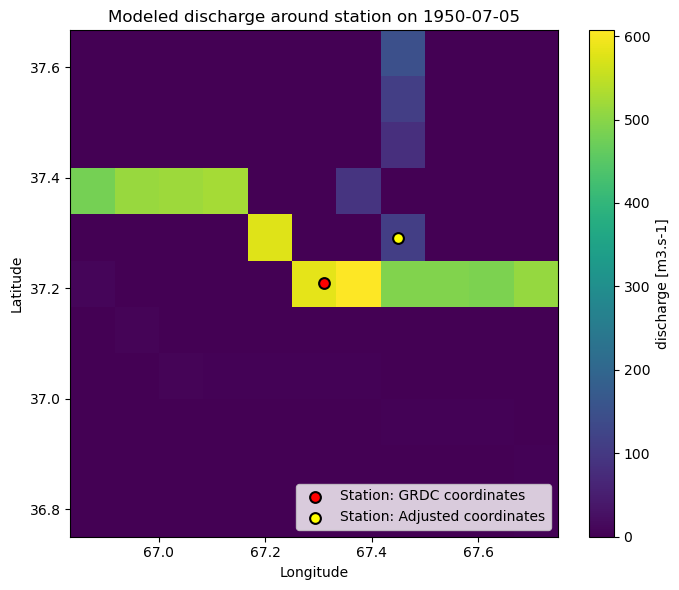

In [300]:
plot_discharge_around_example(da, window=5, time_idx=-180)

In [292]:
start_date = "1949-12-30T00:00Z"
end_date = "1950-12-31T00:00Z"

station_id = 2816203



In [293]:
from pathlib import Path
import pandas as pd
import numpy as np


def read_grdc_monthly_values(start_date, end_date, station_id, data_dir):
    """Read GRDC monthly discharge values for a station and date range (inclusive).
    
    Parameters
    ----------
    start_date : str or datetime-like
        Start date, e.g. "1966-01-01".
    end_date : str or datetime-like
        End date, e.g. "1966-12-31".
    station_id : int or str
        GRDC station id used in file name.
    data_dir : str or Path
        Directory that contains GRDC monthly text files.
    
    Returns
    -------
    pandas.DataFrame
        Columns: date, value
    """
    data_dir = Path(data_dir)
    station_id = str(station_id)

    # Support small naming differences between downloaded GRDC files.
    candidate_names = [
        f"{station_id}_Q_Month.txt",
        f"{station_id}_Q_month.txt",
    ]

    file_path = None
    for name in candidate_names:
        candidate = data_dir / name
        if candidate.exists():
            file_path = candidate
            break

    if file_path is None:
        raise FileNotFoundError(
            f"GRDC file not found in {data_dir}. Tried: {', '.join(candidate_names)}"
        )

    # GRDC text files can contain non-UTF8 symbols; latin-1 safely decodes them.
    df = pd.read_csv(
        file_path,
        sep=';',
        comment='#',
        skipinitialspace=True,
        engine='python',
        encoding='latin-1'
    )

    # Clean column names produced by GRDC header spacing.
    df.columns = [col.strip() for col in df.columns]

    if 'YYYY-MM-DD' not in df.columns:
        raise ValueError(f"Could not find 'YYYY-MM-DD' column in {file_path.name}")

    # Use Original if available and valid; otherwise use Calculated
    original_col = 'Original' if 'Original' in df.columns else None
    calculated_col = 'Calculated' if 'Calculated' in df.columns else None

    df['date'] = pd.to_datetime(df['YYYY-MM-DD'], errors='coerce', utc=True)

    # Prefer Original; merge with Calculated if Original is missing/invalid
    if original_col and calculated_col:
        df['original_val'] = pd.to_numeric(df[original_col], errors='coerce')
        df['calculated_val'] = pd.to_numeric(df[calculated_col], errors='coerce')
        # Use original if valid (not NaN and not -999), otherwise calculated
        df['value'] = df['original_val'].copy()
        mask_use_calc = (df['original_val'].isna()) | (df['original_val'] == -999.0)
        df.loc[mask_use_calc, 'value'] = df.loc[mask_use_calc, 'calculated_val']
    elif original_col:
        df['value'] = pd.to_numeric(df[original_col], errors='coerce')
    elif calculated_col:
        df['value'] = pd.to_numeric(df[calculated_col], errors='coerce')
    else:
        raise ValueError(f"Found neither 'Original' nor 'Calculated' column in {file_path.name}")

    start_ts = pd.to_datetime(start_date, utc=True)
    end_ts = pd.to_datetime(end_date, utc=True)

    out = df.loc[
        (df['date'] >= start_ts)
        & (df['date'] <= end_ts)
        & (df['value'].notna())
        & (df['value'] != -999.0),
        ['date', 'value']
    ].copy()

    out = out.sort_values('date').reset_index(drop=True)
    return out

In [294]:
grdc_data_dir = Path(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/"
    "work_in_progress/data/grdc/Monthly"
    )

grdc_df = read_grdc_monthly_values(
    start_date=start_date,
    end_date=end_date,
    station_id=station_id,
    data_dir=grdc_data_dir,
    )

grdc_df.head(), len(grdc_df)

(                       date   value
 0 1950-01-01 00:00:00+00:00   13.70
 1 1950-02-01 00:00:00+00:00   10.90
 2 1950-03-01 00:00:00+00:00   14.70
 3 1950-04-01 00:00:00+00:00    9.09
 4 1950-05-01 00:00:00+00:00  564.00,
 12)

In [295]:
# Monthly values as a Python list (if needed for metrics)
grdc_values = grdc_df['value'].tolist()
grdc_values

[13.7, 10.9, 14.7, 9.09, 564.0, 444.0, 232.0, 74.0, 21.6, 75.3, 29.7, 8.43]

In [296]:
# Use the same date range for simulated and observed data
test_df = calc_monthly_discharge_at_station(da, 40.21, 69.29, start_date="1950-01-01", end_date="1950-12-31", startup_time_idx=100)

In [297]:
sim = test_df['discharge']  # Skip January to match GRDC data (Feb-Dec only)
obs = grdc_values
mean_error = hm.kge_2009(sim, obs)
print(f"KGE: {mean_error}")

KGE: 0.7011723487808572


In [298]:
sim = test_df['discharge']
obs = grdc_values

print("Simulated:", sim.values)
print("Observed:", obs)

Simulated: [  5.571428   6.823829  16.117504  68.07539  350.0437   434.15076
 471.32245  271.10394  126.96101   36.398502  19.81677   15.230174]
Observed: [13.7, 10.9, 14.7, 9.09, 564.0, 444.0, 232.0, 74.0, 21.6, 75.3, 29.7, 8.43]


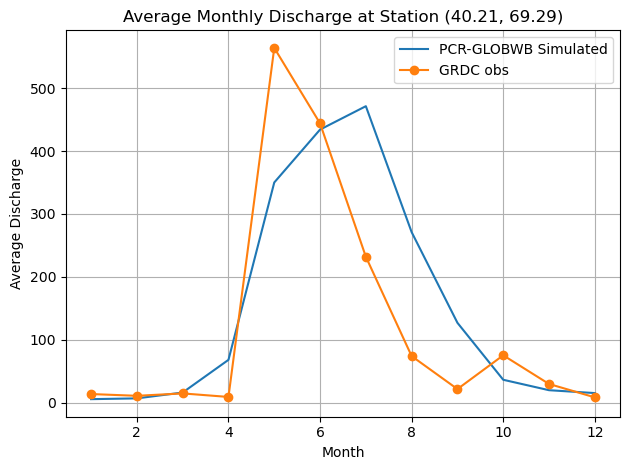

In [299]:
plt.plot(test_df['month'], test_df['discharge'], label='PCR-GLOBWB Simulated')
plt.plot(test_df['month'], grdc_values, label='GRDC obs', marker='o')
plt.xlabel("Month")
plt.ylabel("Average Discharge")
plt.title("Average Monthly Discharge at Station (40.21, 69.29)")
plt.legend()
plt.grid()
plt.tight_layout()